# Implementación de Algoritmos de Aprendizaje en RNA Feedforward

**Tarea IC RNA 2026-1 — Módulo Redes Neuronales Artificiales**
Magíster en Ingeniería Informática — Universidad de Santiago de Chile

**Paper:** Widrow, B. & Lehr, M. A. (1990). *30 Years of Adaptive Neural Networks: Perceptron, Madaline, and Backpropagation.* Proceedings of the IEEE, 78(9), 1415–1442.

**Algoritmos implementados desde cero en NumPy puro:**
1. Regla del Perceptrón (Rosenblatt, 1958)
2. $\alpha$-LMS / Regla Delta de Widrow-Hoff (1960)
3. $\mu$-LMS / Descenso por gradiente estocástico
4. MLP con Backpropagation (Rumelhart, Hinton & Williams, 1986)
5. Madaline Rule II — MRII (Widrow, Winter & Baxter, 1987)
6. Madaline Rule III — MRIII (Andes, 1988) $\equiv$ Backpropagation

**Experimentos:** E1–E7 + Wine Quality + MNIST reducido

## Mapa Experimento $\to$ Sección del Informe

| Exp | Tema | Hipótesis | Figura | Tabla |
|---|---|---|---|---|
| E1 | Capacidad de Cover (Monte Carlo) | H1: $C_s \approx 2N_w$ | `fig_cover.png` | — |
| E2 | Reglas lineales en datos separables | H2: Convergencia finita del Perceptrón | `fig_datasets.png`, `fig_fronteras.png`, `fig_convergencia.png` | `tab_lineales.tex` |
| E3 | Datos no separables | H2: Inestabilidad del Perceptrón vs LMS | `fig_noseparable.png` | — |
| E4 | Superficies de MSE | Fundamento geométrico | `fig_superficies_mse.png` | — |
| E5 | XOR: MLP Backprop + MRII | H3: Poder no lineal + óptimos locales | `fig_xor.png` | `tab_xor.tex` |
| E6 | MLP en Iris + two-moons + Wine + MNIST | Validación en datasets reales | `fig_iris_mlp.png`, `fig_wine.png`, `fig_moons.png`, `fig_mnist.png` | `tab_iris.tex`, `tab_relevancia.tex` |
| E7 | MRIII $\equiv$ Backprop + costo computacional | H4: Equivalencia cuando $\Delta s \to 0$ | `fig_mriii_bp.png` | `tab_mriii.tex` |
| — | Tabla resumen consolidada | — | — | `tab_resumen.tex` |

**Semilla global:** `SEED = 1990` para reproducibilidad exacta.

In [1]:
# ── Imports y configuracion global ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 100})
from scipy.optimize import linprog
from scipy.special import comb as scipy_comb
from sklearn.datasets import load_iris, make_moons, load_wine, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import itertools, time, warnings, os, sys
warnings.filterwarnings('ignore')

# Semilla global
SEED = 1990
np.random.seed(SEED)

# Carpetas de salida
os.makedirs('figs', exist_ok=True)
os.makedirs('tabs', exist_ok=True)

print("✅ Entorno configurado. NumPy", np.__version__)
print("   Carpetas figs/ y tabs/ listas.")

✅ Entorno configurado. NumPy 2.4.4
   Carpetas figs/ y tabs/ listas.


In [2]:
# ── Funciones de utilidad ──

def add_bias(X):
    """Antepone columna de 1s para el bias (x0 = +1)."""
    return np.column_stack([np.ones(len(X)), X])

def accuracy_fn(y_true, y_pred):
    """Fraccion de predicciones correctas."""
    return np.mean(y_true == y_pred)

def mse_loss(y_true, y_pred):
    """Error cuadratico medio."""
    return np.mean((y_true - y_pred) ** 2)

def hamming_error(y_true, y_pred):
    """Numero de patrones mal clasificados."""
    return int(np.sum(y_true != y_pred))

def one_hot(y, n_classes):
    """Convierte etiquetas {0,...,C-1} a one-hot en {-1,+1}."""
    Y = -np.ones((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y

def normalize_features(X_train, X_test):
    """Normaliza al rango [-1, 1] usando min-max del train."""
    xmin = X_train.min(axis=0)
    xmax = X_train.max(axis=0)
    denom = xmax - xmin
    denom[denom == 0] = 1.0
    Xt = 2 * (X_train - xmin) / denom - 1
    Xv = 2 * (X_test - xmin) / denom - 1
    return Xt, Xv

def shuffle_epoch(X, d, rng):
    """Permutacion aleatoria de patrones para una epoca."""
    idx = rng.permutation(len(X))
    return X[idx], d[idx]

def wiener_solution(X_raw, d):
    """Solucion optima de Wiener: W* = R^{-1} P (muestral)."""
    Xb = add_bias(X_raw)
    R = Xb.T @ Xb / len(Xb)
    P = Xb.T @ d / len(Xb)
    try:
        return np.linalg.solve(R, P)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(R, P, rcond=None)[0]

def sigmoid(s):
    """Tangente hiperbolica (tanh)."""
    return np.tanh(s)

def sigmoid_derivative(y):
    """Derivada de tanh: 1 - y^2 (Eq. 55 del paper)."""
    return 1.0 - y ** 2

print("✅ Utilidades definidas.")

✅ Utilidades definidas.


In [3]:
# ── Generacion de datasets sinteticos ──
rng_data = np.random.default_rng(SEED)

def make_separable(n=100):
    """Dos gaussianas bien separadas: N([+/-2,+/-2], 0.35^2 I)."""
    X = np.vstack([
        rng_data.normal([ 2,  2], 0.35, (n, 2)),
        rng_data.normal([-2, -2], 0.35, (n, 2))
    ])
    d = np.array([1]*n + [-1]*n)
    return X, d

def make_nonseparable(n=100):
    """Dos gaussianas solapadas: N([+/-0.9,+/-0.9], 1.3^2 I)."""
    X = np.vstack([
        rng_data.normal([ 0.9,  0.9], 1.3, (n, 2)),
        rng_data.normal([-0.9, -0.9], 1.3, (n, 2))
    ])
    d = np.array([1]*n + [-1]*n)
    return X, d

def make_xor():
    """4 patrones XOR en {-1,+1}^2."""
    X = np.array([[-1,-1], [-1,1], [1,-1], [1,1]], dtype=float)
    d = np.array([-1, 1, 1, -1], dtype=float)
    return X, d

# Generar datasets
X_sep, d_sep = make_separable()
X_nosep, d_nosep = make_nonseparable()
X_xor, d_xor = make_xor()

# Two-moons (scikit-learn)
moons_data = make_moons(n_samples=300, noise=0.20, random_state=SEED)
X_moons, d_moons_raw = moons_data
d_moons = np.where(d_moons_raw == 0, -1.0, 1.0)

print("✅ Datos sinteticos generados:")
print(f"   Separable:     {X_sep.shape[0]} pts, clases +1/-1")
print(f"   No separable:  {X_nosep.shape[0]} pts, clases +1/-1")
print(f"   XOR:           {X_xor.shape[0]} pts, d={d_xor}")
print(f"   Two-moons:     {X_moons.shape[0]} pts")

✅ Datos sinteticos generados:
   Separable:     200 pts, clases +1/-1
   No separable:  200 pts, clases +1/-1
   XOR:           4 pts, d=[-1.  1.  1. -1.]
   Two-moons:     300 pts


In [4]:
# ── Carga y preprocesamiento de datasets reales ──

# === IRIS (Fisher, 1936; UCI) ===
iris = load_iris()
X_iris_raw, y_iris_raw = iris.data, iris.target
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris_raw, y_iris_raw, test_size=0.3, random_state=42, stratify=y_iris_raw)
X_iris_train_n, X_iris_test_n = normalize_features(X_iris_train, X_iris_test)
d_iris_train_oh = one_hot(y_iris_train, 3)
d_iris_test_oh  = one_hot(y_iris_test, 3)

# Subconjuntos binarios para Perceptron
d_setosa_train = np.where(y_iris_train == 0, 1.0, -1.0)
d_setosa_test  = np.where(y_iris_test  == 0, 1.0, -1.0)
mask_vv = (y_iris_train == 1) | (y_iris_train == 2)
X_vv_train = X_iris_train_n[mask_vv]; d_vv_train = np.where(y_iris_train[mask_vv] == 1, 1.0, -1.0)
mask_vv_t  = (y_iris_test  == 1) | (y_iris_test  == 2)
X_vv_test  = X_iris_test_n[mask_vv_t];  d_vv_test  = np.where(y_iris_test[mask_vv_t]   == 1, 1.0, -1.0)

# === WINE (UCI) ===
wine = load_wine()
X_wine_raw, y_wine_raw = wine.data, wine.target
d_wine_bin = np.where(y_wine_raw == 0, 1.0, -1.0)
X_wt, X_wv, d_wt, d_wv = train_test_split(
    X_wine_raw, d_wine_bin, test_size=0.3, random_state=42, stratify=d_wine_bin)
X_wine_train_n, X_wine_test_n = normalize_features(X_wt, X_wv)

# === MNIST reducido (digitos 0-4, 8x8=64 features, UCI) ===
digits = load_digits()
X_digits_raw, y_digits_raw = digits.data, digits.target
mask_04 = y_digits_raw <= 4
X_digits_raw = X_digits_raw[mask_04]; y_digits_raw = y_digits_raw[mask_04]
X_dt, X_dv, y_dt, y_dv = train_test_split(
    X_digits_raw, y_digits_raw, test_size=0.3, random_state=42, stratify=y_digits_raw)
X_digits_train_n, X_digits_test_n = normalize_features(X_dt, X_dv)
d_digits_train_oh = one_hot(y_dt, 5); d_digits_test_oh = one_hot(y_dv, 5)

print("✅ Datos reales cargados y normalizados a [-1,1]:")
print(f"   Iris:        train={X_iris_train_n.shape[0]}, test={X_iris_test_n.shape[0]}, 4 feat, 3 clases")
print(f"   Wine:        train={X_wine_train_n.shape[0]}, test={X_wine_test_n.shape[0]}, 13 feat, binario")
print(f"   MNIST-04:    train={X_digits_train_n.shape[0]}, test={X_digits_test_n.shape[0]}, 64 feat, 5 clases")

✅ Datos reales cargados y normalizados a [-1,1]:
   Iris:        train=105, test=45, 4 feat, 3 clases
   Wine:        train=124, test=54, 13 feat, binario
   MNIST-04:    train=630, test=271, 64 feat, 5 clases


## Algoritmos de Aprendizaje -- Un Solo Elemento

Implementaciones desde cero en NumPy puro de los algoritmos para un unico
elemento adaptativo (Adaline). Todas usan presentacion aleatoria por epoca.
Convencion: $d \in \{-1, +1\}$, entradas con bias $x_0 = +1$.

Referencias: Widrow & Lehr (1990), Secciones IV y VI.

In [5]:
# -------------------------------------------------------------------
# Regla del Perceptron (Rosenblatt, 1958) -- Eq. (18)
# W_{k+1} = W_k + alpha * (epsilon_tilde_k / 2) * X_k
# epsilon_tilde_k = d_k - y_k in {-2, 0, +2}
# Solo adapta si la decision es incorrecta.
# Teorema: converge en pasos finitos si los datos son linealmente
# separables; si no, el vector de pesos tiende a cero.
# -------------------------------------------------------------------

def train_perceptron(X_raw, d, alpha=1.0, max_epochs=200, seed=SEED):
    rng = np.random.default_rng(seed)
    Xb = add_bias(X_raw)
    N, nw = Xb.shape
    W = np.zeros(nw)
    acc_hist, wnorm_hist = [], []
    conv_epoch = -1

    for epoch in range(1, max_epochs + 1):
        Xs, ds = shuffle_epoch(Xb, d, rng)
        errors = 0
        for k in range(N):
            xk, dk = Xs[k], ds[k]
            s = np.dot(xk, W)
            y = np.sign(s) if s != 0 else 1.0
            if y != dk:
                W = W + alpha * ((dk - y) / 2.0) * xk
                errors += 1

        yp = np.sign(np.dot(Xb, W))
        yp[yp == 0] = 1.0
        acc_hist.append(accuracy_fn(d, yp))
        wnorm_hist.append(np.linalg.norm(W))
        if errors == 0 and conv_epoch < 0:
            conv_epoch = epoch

    return W, {
        'epochs_to_converge': conv_epoch,
        'acc_history': np.array(acc_hist),
        'w_norm_history': np.array(wnorm_hist)
    }

# Test rapido
Wp_test, hp_test = train_perceptron(X_sep, d_sep)
print(f"Perceptron separable: converge en {hp_test['epochs_to_converge']} epocas, acc={hp_test['acc_history'][-1]:.4f}")


Perceptron separable: converge en 2 epocas, acc=1.0000


In [6]:
# -------------------------------------------------------------------
# alpha-LMS / Regla Delta de Widrow-Hoff (1960) -- Eq. (10)
# W_{k+1} = W_k + alpha * (epsilon_k / ||X_k||^2) * X_k
# epsilon_k = d_k - s_k  (error LINEAL)
# Rango estable: 0 < alpha < 2. Practico: 0.1 < alpha < 1.0.
# Cambio de peso colineal con X_k = minima perturbacion geometrica.
# -------------------------------------------------------------------

def train_alpha_lms(X_raw, d, alpha=0.5, max_epochs=200, seed=SEED):
    rng = np.random.default_rng(seed)
    Xb = add_bias(X_raw)
    N, nw = Xb.shape
    W = np.zeros(nw)
    mse_hist, acc_hist, wnorm_hist = [], [], []

    for epoch in range(1, max_epochs + 1):
        Xs, ds = shuffle_epoch(Xb, d, rng)
        for k in range(N):
            xk, dk = Xs[k], ds[k]
            s = np.dot(xk, W)
            eps = dk - s
            W = W + alpha * (eps / np.dot(xk, xk)) * xk

        s_all = np.dot(Xb, W)
        mse_hist.append(mse_loss(d, s_all))
        yp = np.sign(s_all); yp[yp == 0] = 1.0
        acc_hist.append(accuracy_fn(d, yp))
        wnorm_hist.append(np.linalg.norm(W))

    return W, {
        'mse_history': np.array(mse_hist),
        'acc_history': np.array(acc_hist),
        'w_norm_history': np.array(wnorm_hist)
    }

Wa_test, ha_test = train_alpha_lms(X_sep, d_sep, alpha=0.5)
print(f"alpha-LMS separable: MSE={ha_test['mse_history'][-1]:.6f}, acc={ha_test['acc_history'][-1]:.4f}")


alpha-LMS separable: MSE=0.022619, acc=1.0000


In [7]:
# -------------------------------------------------------------------
# mu-LMS / Descenso por gradiente estocastico -- Eq. (33)
# W_{k+1} = W_k + 2*mu * epsilon_k * X_k
# Estabilidad: 0 < mu < 1/tr[R].
# Superficie MSE: hiperparaboloide CONVEXO, unico minimo global W*.
# Gradiente instantaneo: INSESGADO.
# -------------------------------------------------------------------

def train_mu_lms(X_raw, d, mu=0.01, max_epochs=200, seed=SEED):
    rng = np.random.default_rng(seed)
    Xb = add_bias(X_raw)
    N, nw = Xb.shape
    W = np.zeros(nw)
    mse_hist, acc_hist, wnorm_hist = [], [], []
    w_traj = [W.copy()]

    for epoch in range(1, max_epochs + 1):
        Xs, ds = shuffle_epoch(Xb, d, rng)
        for k in range(N):
            xk, dk = Xs[k], ds[k]
            s = np.dot(xk, W)
            eps = dk - s
            W = W + 2 * mu * eps * xk

        s_all = np.dot(Xb, W)
        mse_hist.append(mse_loss(d, s_all))
        yp = np.sign(s_all); yp[yp == 0] = 1.0
        acc_hist.append(accuracy_fn(d, yp))
        wnorm_hist.append(np.linalg.norm(W))
        if epoch <= 50:
            w_traj.append(W.copy())

    return W, {
        'mse_history': np.array(mse_hist),
        'acc_history': np.array(acc_hist),
        'w_norm_history': np.array(wnorm_hist),
        'weight_trajectory': np.array(w_traj)
    }

Wmu_test, hmu_test = train_mu_lms(X_sep, d_sep, mu=0.02)
print(f"mu-LMS separable: MSE={hmu_test['mse_history'][-1]:.6f}, acc={hmu_test['acc_history'][-1]:.4f}")


mu-LMS separable: MSE=0.019502, acc=1.0000


## Algoritmos de Aprendizaje -- Redes Multicapa

Implementaciones desde cero en NumPy puro:
1. **MLP con Backpropagation** (Rumelhart, Hinton & Williams, 1986)
2. **Madaline Rule II -- MRII** (Widrow, Winter & Baxter, 1987)
3. **Madaline Rule III -- MRIII** (Andes, 1988) $\equiv$ Backpropagation

Referencias: Widrow & Lehr (1990), Secciones V, VI y VII.

In [8]:
# -------------------------------------------------------------------
# MLP con Backpropagation
# Deltas: salida delta^(L) = eps * sgm'(s), Eq. 78/79
#         ocultas delta^(l) = (W^(l+1)^T * delta^(l+1)) .* sgm'(s^(l)), Eq. 87
# Actualizacion: DeltaW = 2*mu * delta * x^T, Eq. 94
# Momentum: V = eta*V + (1-eta)*2*mu*delta*x^T, Eqs. 96-97
# -------------------------------------------------------------------

class MLP:
    def __init__(self, layer_sizes, mu=0.01, momentum=0.0, seed=SEED):
        self.L = len(layer_sizes) - 1
        self.mu = mu
        self.momentum = momentum
        self.rng = np.random.default_rng(seed)
        self.W = []
        self.V = []
        for l in range(self.L):
            n_in_l = layer_sizes[l] + 1
            n_out_l = layer_sizes[l + 1]
            Wl = self.rng.uniform(-0.5, 0.5, (n_out_l, n_in_l))
            self.W.append(Wl)
            self.V.append(np.zeros_like(Wl))

    def forward(self, x):
        acts = [np.append(1.0, x)]
        sums = []
        a = x.copy()
        for l in range(self.L):
            a_bias = np.append(1.0, a)
            s = self.W[l] @ a_bias
            sums.append(s)
            a = sigmoid(s)
            acts.append(np.append(1.0, a))
        return acts, sums

    def _backprop_deltas(self, acts, sums, d_target):
        deltas = [None] * self.L
        y_out = acts[-1][1:]
        eps = d_target - y_out
        deltas[-1] = eps * sigmoid_derivative(y_out)

        for l in range(self.L - 2, -1, -1):
            y_hidden = acts[l + 1][1:]
            W_next = self.W[l + 1][:, 1:]
            delta_next = deltas[l + 1]
            deltas[l] = (W_next.T @ delta_next) * sigmoid_derivative(y_hidden)

        return deltas

    def train_pattern(self, x, d_target):
        acts, sums = self.forward(x)
        deltas = self._backprop_deltas(acts, sums, d_target)
        for l in range(self.L):
            a_in = acts[l]
            delta = deltas[l]
            dw = 2 * self.mu * np.outer(delta, a_in)
            if self.momentum > 0:
                self.V[l] = self.momentum * self.V[l] + (1 - self.momentum) * dw
                self.W[l] += self.V[l]
            else:
                self.W[l] += dw

    def fit(self, X, d, epochs=100, verbose=False, seed=None):
        rng_fit = np.random.default_rng(seed if seed is not None else SEED)
        N = len(X)
        mse_hist, acc_hist = [], []
        for ep in range(1, epochs + 1):
            idx = rng_fit.permutation(N)
            for k in idx:
                self.train_pattern(X[k], d[k])
            preds = self.predict_batch(X)
            mse_hist.append(mse_loss(d, preds))
            if d.ndim == 2 and d.shape[1] > 1:
                acc_hist.append(self.accuracy(X, d))
            else:
                yp = np.sign(preds.flatten()); yp[yp == 0] = 1.0
                acc_hist.append(accuracy_fn(d.flatten(), yp))
            if verbose and ep % max(1, epochs//10) == 0:
                print(f"  Ep {ep:4d}/{epochs}: MSE={mse_hist[-1]:.6f}, acc={acc_hist[-1]:.4f}")
        return {'mse_history': np.array(mse_hist), 'acc_history': np.array(acc_hist)}

    def predict_batch(self, X):
        preds = np.zeros((len(X), self.W[-1].shape[0]))
        for i in range(len(X)):
            acts, _ = self.forward(X[i])
            preds[i] = acts[-1][1:]
        return preds

    def accuracy(self, X, d_onehot):
        preds = self.predict_batch(X)
        y_pred = np.argmax(preds, axis=1)
        y_true = np.argmax(d_onehot, axis=1) if d_onehot.ndim == 2 else np.where(d_onehot > 0, 1, 0)
        return accuracy_fn(y_true, y_pred)

# Test rapido XOR
mlp_test = MLP([2, 2, 1], mu=0.1, momentum=0.0)
hist_test = mlp_test.fit(X_xor, d_xor.reshape(-1,1), epochs=400)
print(f"MLP(2,2,1) XOR: MSE={hist_test['mse_history'][-1]:.6f}, acc={hist_test['acc_history'][-1]:.4f}")


MLP(2,2,1) XOR: MSE=1.003420, acc=0.5000


In [9]:
# -------------------------------------------------------------------
# Madaline Rule II -- MRII (Widrow, Winter & Baxter, 1987)
# Red feedforward de Adalines con cuantizador signum en TODAS las capas.
#
# Algoritmo por patron erroneo:
#   1. Ordenar Adalines ocultas por |s| creciente (load-sharing).
#   2. Inversion tentativa (flip) de 1 Adaline, luego de pares.
#   3. Si reduce Hamming: aceptar + correccion absoluta colineal.
#   4. Capa de salida: alpha-LMS.
#   5. Escape de optimos locales: ruido gaussiano si Hamming se estanca.
# -------------------------------------------------------------------

class MadalineII:
    def __init__(self, layer_sizes, seed=SEED):
        self.L = len(layer_sizes) - 1
        self.rng = np.random.default_rng(seed)
        self.W = []
        for l in range(self.L):
            n_in = layer_sizes[l] + 1
            n_out = layer_sizes[l + 1]
            self.W.append(self.rng.uniform(-0.5, 0.5, (n_out, n_in)))

    def forward(self, x, flip=None):
        a = x.copy()
        last_s = None
        for l in range(self.L):
            a_bias = np.append(1.0, a)
            s = self.W[l] @ a_bias
            y = np.sign(s); y[y == 0] = 1.0
            if flip is not None and flip[0] == l:
                for idx in flip[1]:
                    y[idx] = -y[idx]
            a = y
            last_s = s
        return a, last_s

    def _all_suminders(self, x):
        all_s = []
        a = x.copy()
        for l in range(self.L):
            a_bias = np.append(1.0, a)
            s = self.W[l] @ a_bias
            all_s.append((l, s))
            y = np.sign(s); y[y == 0] = 1.0
            a = y
        return all_s

    def _reinforce(self, x, layer, adaline_idx):
        a = x.copy()
        for l in range(layer):
            a_b = np.append(1.0, a)
            s_l = self.W[l] @ a_b
            y_l = np.sign(s_l); y_l[y_l == 0] = 1.0
            a = y_l
        a_bias = np.append(1.0, a)
        s = self.W[layer][adaline_idx] @ a_bias
        target = -np.sign(s) if np.sign(s) != 0 else 1.0
        margin = 1.0
        denom = np.dot(a_bias, a_bias)
        if denom > 0:
            self.W[layer][adaline_idx] += ((target * margin - s) / denom) * a_bias

    def fit(self, X, d, max_epochs=150, alpha_out=0.5, patience=15,
            noise_sigma=0.15, verbose=False, seed=None):
        rng = np.random.default_rng(seed if seed is not None else SEED)
        N = len(X)
        hamming_hist, acc_hist = [], []
        best_W = [W.copy() for W in self.W]
        best_hamming = N + 1
        stall_count = 0

        for ep in range(1, max_epochs + 1):
            idx = rng.permutation(N)
            for k in idx:
                xk, dk = X[k], d[k]
                y_out, _ = self.forward(xk)
                if np.sign(y_out) == dk:
                    continue

                all_s = self._all_suminders(xk)
                hidden_layers = [(l, s) for l, s in all_s if l < self.L - 1]

                if not hidden_layers:
                    a_bias = np.append(1.0, xk)
                    s_out = self.W[-1] @ a_bias
                    eps = dk - s_out
                    denom = np.dot(a_bias, a_bias)
                    if denom > 0:
                        self.W[-1] += alpha_out * (eps / denom) * a_bias
                    continue

                # Ordenar por |s| creciente
                flat_ada = []
                for l, s in hidden_layers:
                    for j in range(len(s)):
                        flat_ada.append((l, j, abs(s[j])))
                flat_ada.sort(key=lambda x: x[2])

                # Inversiones individuales
                accepted = False
                for l, j, _ in flat_ada:
                    y_tent, _ = self.forward(xk, flip=(l, [j]))
                    if np.sign(y_tent) == dk:
                        self._reinforce(xk, l, j)
                        accepted = True
                        break

                # Inversiones de a pares
                if not accepted and len(flat_ada) >= 2:
                    import itertools
                    for (l1, j1, _), (l2, j2, _) in itertools.combinations(flat_ada, 2):
                        if l1 == l2:
                            y_tent, _ = self.forward(xk, flip=(l1, [j1, j2]))
                        else:
                            self.forward(xk, flip=(l1, [j1]))
                            y_tent, _ = self.forward(xk, flip=(l2, [j2]))
                        if np.sign(y_tent) == dk:
                            self._reinforce(xk, l1, j1)
                            self._reinforce(xk, l2, j2)
                            accepted = True
                            break

                # alpha-LMS en salida si no se acepto
                if not accepted:
                    a = xk.copy()
                    for l in range(self.L - 1):
                        a_b = np.append(1.0, a)
                        s_l = self.W[l] @ a_b
                        y_l = np.sign(s_l); y_l[y_l == 0] = 1.0
                        a = y_l
                    a_out = np.append(1.0, a)
                    s_out = self.W[-1] @ a_out
                    eps = dk - s_out
                    denom = np.dot(a_out, a_out)
                    if denom > 0:
                        self.W[-1] += alpha_out * (eps / denom) * a_out

            # Evaluacion de epoca
            y_all = np.array([np.sign(self.forward(X[i])[0]) for i in range(N)])
            h = int(np.sum(d != y_all))
            acc = accuracy_fn(d, y_all)
            hamming_hist.append(h)
            acc_hist.append(acc)

            if h < best_hamming:
                best_hamming = h
                best_W = [W.copy() for W in self.W]
                stall_count = 0
            else:
                stall_count += 1

            if stall_count >= patience:
                for Wl in self.W:
                    Wl += rng.normal(0, noise_sigma, Wl.shape)
                stall_count = 0
                if verbose:
                    print(f"  Ep {ep}: escape ruido sigma={noise_sigma}")

            if verbose and ep % 20 == 0:
                print(f"  Ep {ep:3d}: Hamming={h}, acc={acc:.4f}, stall={stall_count}")

        self.W = best_W
        return {
            'hamming_history': np.array(hamming_hist),
            'acc_history': np.array(acc_hist),
            'best_hamming': best_hamming
        }

    def predict(self, X):
        return np.array([np.sign(self.forward(x)[0]) for x in X])

print("Clase MadalineII definida.")


Clase MadalineII definida.


In [10]:
# -------------------------------------------------------------------
# Madaline Rule III -- MRIII (Andes, 1988) EQUIVALENTE a Backprop
# Estima d(eps^2)/ds_j perturbando el sumidero de cada Adaline.
# Eq. 102: d(eps^2)/ds_j ~= (eps^2_pert - eps^2_base) / Delta_s
# Cuando Delta_s -> 0: MRIII == backprop (demostrado por Widrow).
# -------------------------------------------------------------------

def mriii_gradient(net, x, d_target, ds=1e-6):
    acts_base, sums_base = net.forward(x)
    y_base = acts_base[-1][1:]
    eps_base = d_target - y_base
    eps2_base = np.sum(eps_base ** 2)

    grads = []
    for l in range(net.L):
        n_ada = net.W[l].shape[0]
        grad_l = np.zeros(n_ada)

        for j in range(n_ada):
            a = x.copy()
            for ll in range(net.L):
                a_bias = np.append(1.0, a)
                s = net.W[ll] @ a_bias
                if ll == l:
                    s[j] += ds
                a = sigmoid(s)
            eps_pert = d_target - a
            eps2_pert = np.sum(eps_pert ** 2)
            grad_l[j] = (eps2_pert - eps2_base) / ds

        grads.append(grad_l)
    return grads, eps2_base

def backprop_gradient(net, x, d_target):
    acts, sums = net.forward(x)
    deltas = net._backprop_deltas(acts, sums, d_target)
    return [-2.0 * d for d in deltas]

print("Funciones MRIII definidas.")


Funciones MRIII definidas.


---
## Experimentos

A continuacion se ejecutan los experimentos E1 a E7, mas Wine Quality y MNIST reducido.
Cada experimento genera sus figuras en `figs/` y/o tablas LaTeX en `tabs/`.
Los resultados se referencian desde el informe.

E1: Capacidad de Cover -- Monte Carlo


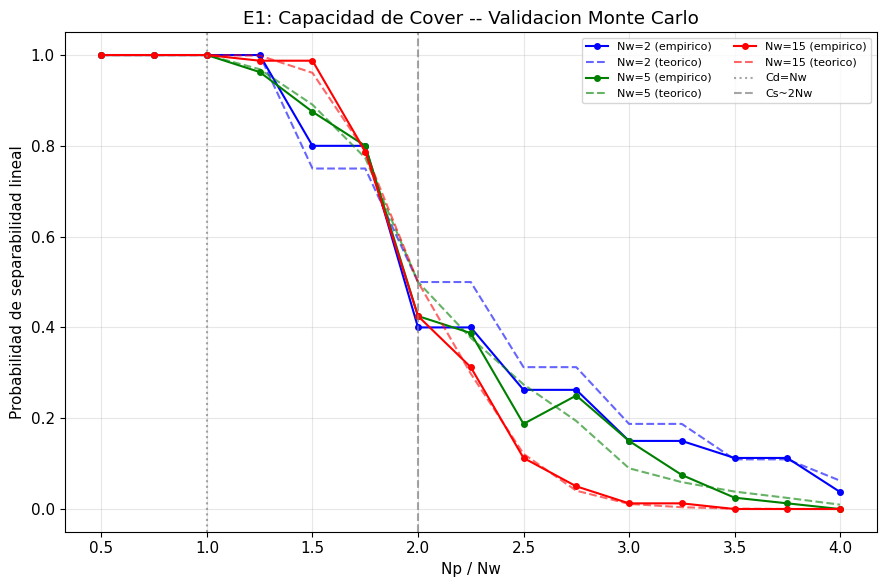

  Nw= 2: desviacion media |emp-teo| = 0.0337
  Nw= 5: desviacion media |emp-teo| = 0.0259
  Nw=15: desviacion media |emp-teo| = 0.0105
E1 completado. Figura: figs/fig_cover.png


In [11]:
# ===================================================================
# E1: CAPACIDAD DE COVER (H1: C_s ~ 2*N_w, C_d = N_w)
# ===================================================================
print("="*60)
print("E1: Capacidad de Cover -- Monte Carlo")
print("="*60)

def check_separable(X, d):
    """Test de separabilidad lineal via LP."""
    N, n = X.shape
    c = np.zeros(n)
    A_ub = -d.reshape(-1, 1) * X
    b_ub = -np.ones(N)
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(None, None), method='highs')
    return res.success

def cover_theory(Np, Nw):
    """Probabilidad teorica de separabilidad (Cover, 1964)."""
    if Np <= Nw:
        return 1.0
    s = 0.0
    for i in range(Nw):
        s += scipy_comb(Np - 1, i, exact=False)
    return 2.0 ** (1 - Np) * s

# Parametros
Nw_list = [2, 5, 15]
ratios = np.arange(0.5, 4.01, 0.25)
n_trials = 80
results = {}

for Nw in Nw_list:
    probs = []
    for ratio in ratios:
        Np = max(1, int(ratio * Nw))
        sep_count = 0
        for trial in range(n_trials):
            rng_e1 = np.random.default_rng(SEED + trial)
            X = rng_e1.normal(0, 1, (Np, Nw))
            d = np.where(rng_e1.random(Np) > 0.5, 1.0, -1.0)
            if check_separable(X, d):
                sep_count += 1
        probs.append(sep_count / n_trials)
    results[Nw] = probs

# Grafico
fig, ax = plt.subplots(figsize=(9, 6))
colors = {2: 'blue', 5: 'green', 15: 'red'}
for Nw in Nw_list:
    ax.plot(ratios, results[Nw], 'o-', color=colors[Nw], markersize=4,
            label=f'Nw={Nw} (empirico)')
    theory = [cover_theory(int(max(1, r*Nw)), Nw) for r in ratios]
    ax.plot(ratios, theory, '--', color=colors[Nw], alpha=0.6,
            label=f'Nw={Nw} (teorico)')

ax.axvline(x=1.0, color='gray', linestyle=':', alpha=0.7, label='Cd=Nw')
ax.axvline(x=2.0, color='gray', linestyle='--', alpha=0.7, label='Cs~2Nw')
ax.set_xlabel('Np / Nw')
ax.set_ylabel('Probabilidad de separabilidad lineal')
ax.set_title('E1: Capacidad de Cover -- Validacion Monte Carlo')
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/fig_cover.png', dpi=200, bbox_inches='tight')
plt.show()

for Nw in Nw_list:
    theory_vals = np.array([cover_theory(int(max(1, r*Nw)), Nw) for r in ratios])
    dev = np.mean(np.abs(np.array(results[Nw]) - theory_vals))
    print(f"  Nw={Nw:2d}: desviacion media |emp-teo| = {dev:.4f}")

print("E1 completado. Figura: figs/fig_cover.png")



E2: Reglas lineales en datos separables
Angulos vs W*: Perceptron=20.6deg, alpha-LMS=4.4deg, mu-LMS=3.5deg
tr[R]=9.0234, mu_max=1/tr[R]=0.110822
MSE Wiener=0.014834


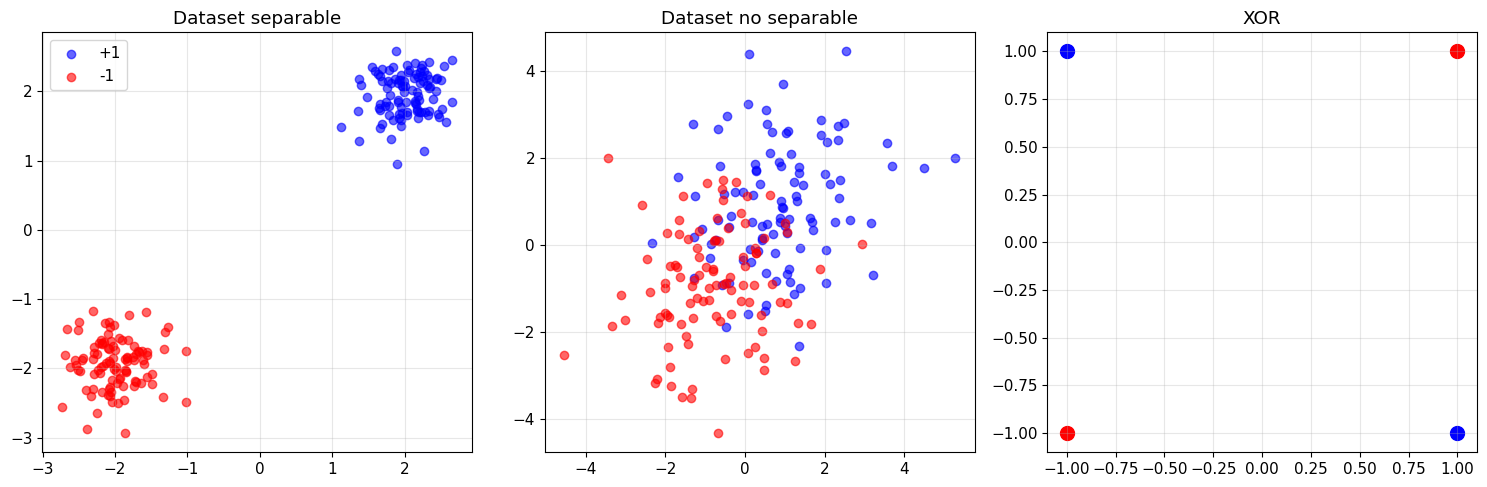

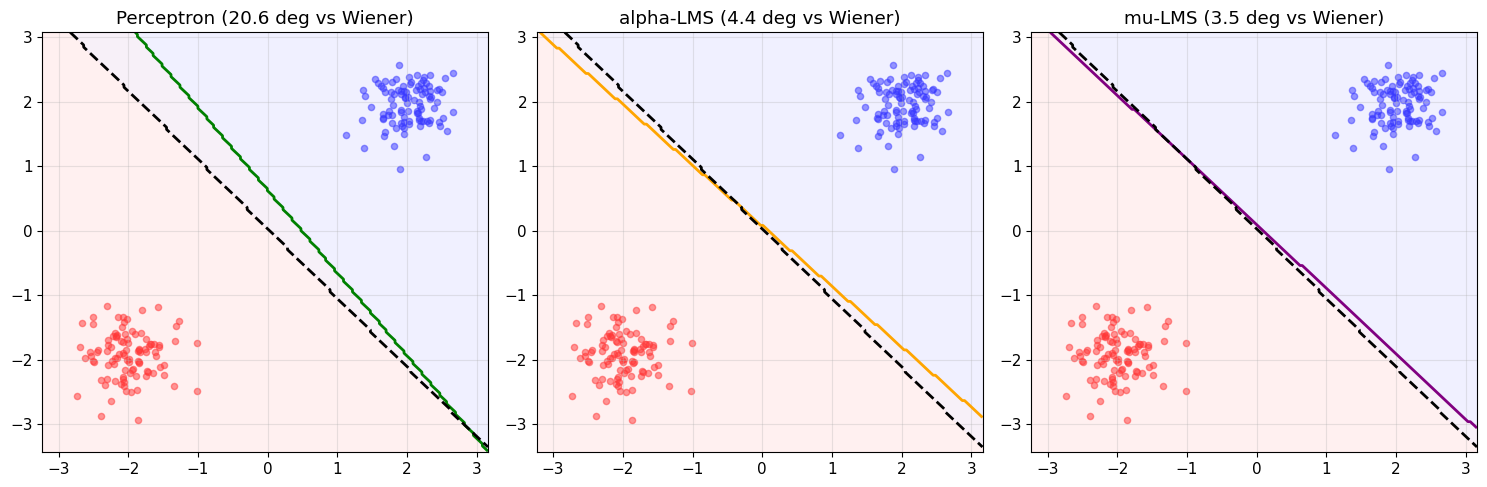


Probando mu-LMS con distintos mu...


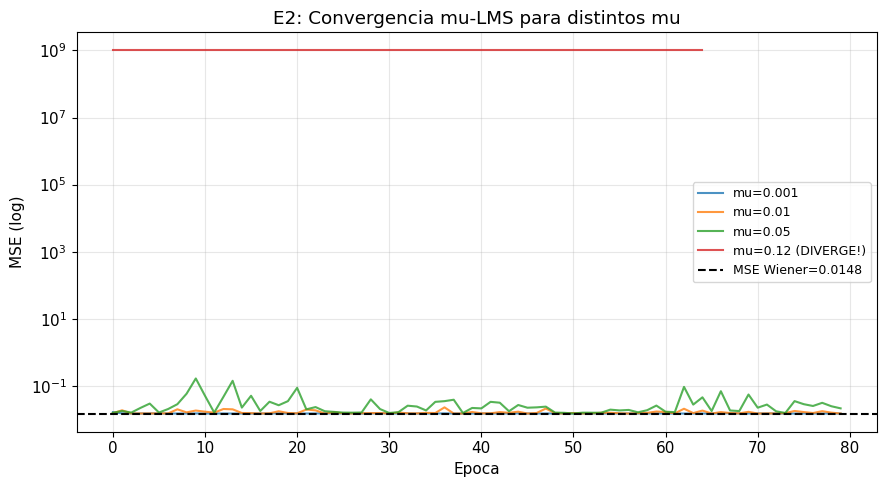

E2 completado.


In [12]:
# ===================================================================
# E2: REGLAS LINEALES EN DATOS SEPARABLES (H2)
# ===================================================================
print("\n" + "="*60)
print("E2: Reglas lineales en datos separables")
print("="*60)

# Entrenar los 3 algoritmos
W_perceptron, hp = train_perceptron(X_sep, d_sep, alpha=1.0, max_epochs=100)
W_alpha, ha = train_alpha_lms(X_sep, d_sep, alpha=0.5, max_epochs=100)
W_mu, hm = train_mu_lms(X_sep, d_sep, mu=0.02, max_epochs=100)
W_wiener = wiener_solution(X_sep, d_sep)

# Angulo respecto a W*
def angle_between(w1, w2):
    cos_ang = np.dot(w1, w2) / (np.linalg.norm(w1) * np.linalg.norm(w2))
    return np.degrees(np.arccos(np.clip(cos_ang, -1, 1)))

ang_p = angle_between(W_perceptron, W_wiener)
ang_a = angle_between(W_alpha, W_wiener)
ang_m = angle_between(W_mu, W_wiener)
print(f"Angulos vs W*: Perceptron={ang_p:.1f}deg, alpha-LMS={ang_a:.1f}deg, mu-LMS={ang_m:.1f}deg")

# Calcular tr[R] y mu_max
Xb = add_bias(X_sep)
R = Xb.T @ Xb / len(Xb)
trR = np.trace(R)
mu_max_theory = 1.0 / trR
mse_wiener = mse_loss(d_sep, np.dot(Xb, W_wiener))
print(f"tr[R]={trR:.4f}, mu_max=1/tr[R]={mu_max_theory:.6f}")
print(f"MSE Wiener={mse_wiener:.6f}")

# Figura 1: Datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(X_sep[d_sep==1,0], X_sep[d_sep==1,1], c='blue', alpha=0.6, label='+1')
axes[0].scatter(X_sep[d_sep==-1,0], X_sep[d_sep==-1,1], c='red', alpha=0.6, label='-1')
axes[0].set_title('Dataset separable'); axes[0].legend()
axes[1].scatter(X_nosep[d_nosep==1,0], X_nosep[d_nosep==1,1], c='blue', alpha=0.6)
axes[1].scatter(X_nosep[d_nosep==-1,0], X_nosep[d_nosep==-1,1], c='red', alpha=0.6)
axes[1].set_title('Dataset no separable')
axes[2].scatter(X_xor[d_xor==1,0], X_xor[d_xor==1,1], c='blue', s=100)
axes[2].scatter(X_xor[d_xor==-1,0], X_xor[d_xor==-1,1], c='red', s=100)
axes[2].set_title('XOR')
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_datasets.png', dpi=200, bbox_inches='tight'); plt.show()

# Figura 2: Fronteras de decision
def plot_boundary(ax, W, X, d, color, ls='-'):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    s_grid = np.dot(add_bias(grid), W)
    Z = np.sign(s_grid).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], colors=color, linestyles=ls, linewidths=2)
    ax.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=['#FFCCCC','#CCCCFF'], alpha=0.15)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Perceptron', 'alpha-LMS', 'mu-LMS']
Ws = [W_perceptron, W_alpha, W_mu]
angs = [ang_p, ang_a, ang_m]
colors_b = ['green', 'orange', 'purple']
for i, (ax, W, title, c, a) in enumerate(zip(axes, Ws, titles, colors_b, angs)):
    ax.scatter(X_sep[d_sep==1,0], X_sep[d_sep==1,1], c='blue', alpha=0.5, s=20)
    ax.scatter(X_sep[d_sep==-1,0], X_sep[d_sep==-1,1], c='red', alpha=0.5, s=20)
    plot_boundary(ax, W, X_sep, d_sep, c)
    plot_boundary(ax, W_wiener, X_sep, d_sep, 'black', '--')
    ax.set_title(f'{title} ({a:.1f} deg vs Wiener)')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_fronteras.png', dpi=200, bbox_inches='tight'); plt.show()

# Figura 3: Convergencia mu-LMS para distintos mu
print("\nProbando mu-LMS con distintos mu...")
mu_values = [0.001, 0.01, 0.05, 0.12]
fig, ax = plt.subplots(figsize=(9, 5))
for mu in mu_values:
    with np.errstate(over='ignore', invalid='ignore'):
        _, hm_tmp = train_mu_lms(X_sep, d_sep, mu=mu, max_epochs=80)
        mse_clipped = np.clip(hm_tmp['mse_history'], 0, 1e9)
        label = f'mu={mu}' + (' (DIVERGE!)' if mu > mu_max_theory else '')
        ax.semilogy(mse_clipped, label=label, alpha=0.8)
ax.axhline(y=mse_wiener, color='black', linestyle='--', label=f'MSE Wiener={mse_wiener:.4f}')
ax.set_xlabel('Epoca'); ax.set_ylabel('MSE (log)')
ax.set_title('E2: Convergencia mu-LMS para distintos mu')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_convergencia.png', dpi=200, bbox_inches='tight'); plt.show()
print("E2 completado.")


\n============================================================
E3: Datos no separables
Accuracy (media +/- std, ultimas 40 epocas):
  Perceptron: 75.7% +/- 5.5
  alpha-LMS:  75.0% +/- 7.4
  mu-LMS:     79.6% +/- 1.5
  Wiener:     81.0%


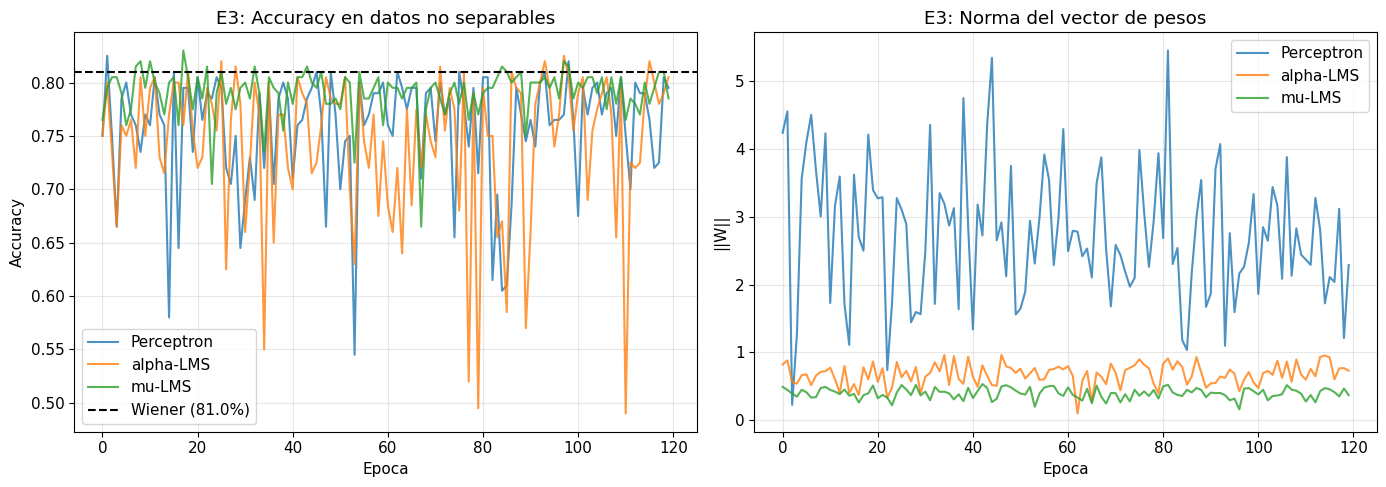

Tabla: tabs/tab_lineales.tex
E3 completado.


In [14]:
# ===================================================================
# E3: DATOS NO SEPARABLES (H2: inestabilidad Perceptron vs LMS)
# ===================================================================
print("\\n" + "="*60)
print("E3: Datos no separables")
print("="*60)

max_ep = 120
Wp_ns, hp_ns = train_perceptron(X_nosep, d_nosep, alpha=1.0, max_epochs=max_ep)
Wa_ns, ha_ns = train_alpha_lms(X_nosep, d_nosep, alpha=0.5, max_epochs=max_ep)
Wm_ns, hm_ns = train_mu_lms(X_nosep, d_nosep, mu=0.02, max_epochs=max_ep)
W_wiener_ns = wiener_solution(X_nosep, d_nosep)

Xb_ns = add_bias(X_nosep)
yp_wiener_ns = np.sign(np.dot(Xb_ns, W_wiener_ns))
yp_wiener_ns[yp_wiener_ns==0] = 1.0
acc_wiener_ns = accuracy_fn(d_nosep, yp_wiener_ns)

def last40_stats(hist):
    return np.mean(hist[-40:]), np.std(hist[-40:])

pa_m, pa_s = last40_stats(hp_ns['acc_history'])
aa_m, aa_s = last40_stats(ha_ns['acc_history'])
ma_m, ma_s = last40_stats(hm_ns['acc_history'])

print(f"Accuracy (media +/- std, ultimas 40 epocas):")
print(f"  Perceptron: {pa_m*100:.1f}% +/- {pa_s*100:.1f}")
print(f"  alpha-LMS:  {aa_m*100:.1f}% +/- {aa_s*100:.1f}")
print(f"  mu-LMS:     {ma_m*100:.1f}% +/- {ma_s*100:.1f}")
print(f"  Wiener:     {acc_wiener_ns*100:.1f}%")

# Figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(hp_ns['acc_history'], label='Perceptron', alpha=0.8)
ax1.plot(ha_ns['acc_history'], label='alpha-LMS', alpha=0.8)
ax1.plot(hm_ns['acc_history'], label='mu-LMS', alpha=0.8)
ax1.axhline(y=acc_wiener_ns, color='black', linestyle='--', label=f'Wiener ({acc_wiener_ns*100:.1f}%)')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Accuracy')
ax1.set_title('E3: Accuracy en datos no separables')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(hp_ns['w_norm_history'], label='Perceptron', alpha=0.8)
ax2.plot(ha_ns['w_norm_history'], label='alpha-LMS', alpha=0.8)
ax2.plot(hm_ns['w_norm_history'], label='mu-LMS', alpha=0.8)
ax2.set_xlabel('Epoca'); ax2.set_ylabel('||W||')
ax2.set_title('E3: Norma del vector de pesos')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_noseparable.png', dpi=200, bbox_inches='tight'); plt.show()

# Tabla lineales LaTeX
tab_lines = []
tab_lines.append('\\\\begin{tabular}{@{}lccc@{}}')
tab_lines.append('\\\\toprule')
tab_lines.append('Algoritmo & Acc. separable & Ep. converg. & Acc. no separable \\\\\\\\')
tab_lines.append('\\\\midrule')
tab_lines.append(f'Perceptron & 100.0\\\\% & {hp["epochs_to_converge"]} & {pa_m*100:.1f}\\\\% $\\\\pm${pa_s*100:.1f} \\\\\\\\')
tab_lines.append(f'$\\\\alpha$-LMS & 100.0\\\\% & -- & {aa_m*100:.1f}\\\\% $\\\\pm${aa_s*100:.1f} \\\\\\\\')
tab_lines.append(f'$\\\\mu$-LMS & 100.0\\\\% & -- & {ma_m*100:.1f}\\\\% $\\\\pm${ma_s*100:.1f} \\\\\\\\')
tab_lines.append('\\\\midrule')
tab_lines.append(f'Wiener (optimo) & 100.0\\\\% & -- & {acc_wiener_ns*100:.1f}\\\\% \\\\\\\\')
tab_lines.append('\\\\bottomrule')
tab_lines.append('\\\\end{tabular}')
with open('tabs/tab_lineales.tex', 'w', encoding='utf-8') as f:
    f.write('\\n'.join(tab_lines))
print("Tabla: tabs/tab_lineales.tex")
print("E3 completado.")


E4: Superficies de MSE
Minimos MSE: lineal=0.9359, sigmoide=0.9401, signum=1.3333


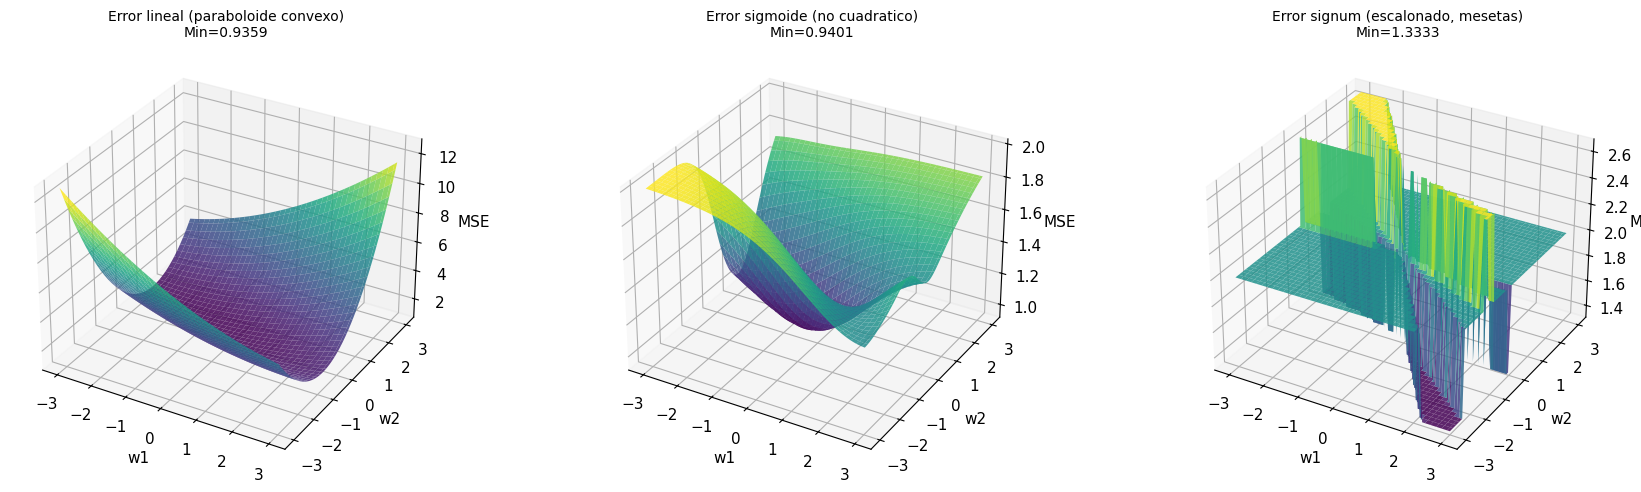

E4 completado. Figura: figs/fig_superficies_mse.png


In [15]:
# ===================================================================
# E4: SUPERFICIES DE MSE (Figs. 22-24 del paper)
# ===================================================================
print("\n" + "="*60)
print("E4: Superficies de MSE")
print("="*60)

# Adaline de 2 pesos sin bias, 6 patrones aleatorios
rng_e4 = np.random.default_rng(7)
X_e4 = rng_e4.normal(0, 1, (6, 2))
d_e4 = np.where(rng_e4.random(6) > 0.5, 1.0, -1.0)

w1 = np.linspace(-3, 3, 80)
w2 = np.linspace(-3, 3, 80)
W1, W2 = np.meshgrid(w1, w2)

MSE_linear = np.zeros_like(W1)
MSE_sigmoid = np.zeros_like(W1)
MSE_signum = np.zeros_like(W1)

for i in range(len(w1)):
    for j in range(len(w2)):
        w = np.array([w1[i], w2[j]])
        s = X_e4 @ w  # sin bias
        MSE_linear[j, i] = np.mean((d_e4 - s) ** 2)
        MSE_sigmoid[j, i] = np.mean((d_e4 - np.tanh(s)) ** 2)
        MSE_signum[j, i] = np.mean((d_e4 - np.sign(s)) ** 2)

min_lin = MSE_linear.min()
min_sig = MSE_sigmoid.min()
min_sgn = MSE_signum.min()
print(f"Minimos MSE: lineal={min_lin:.4f}, sigmoide={min_sig:.4f}, signum={min_sgn:.4f}")

fig = plt.figure(figsize=(18, 5))
titles = ['Error lineal (paraboloide convexo)', 'Error sigmoide (no cuadratico)', 'Error signum (escalonado, mesetas)']
data = [MSE_linear, MSE_sigmoid, MSE_signum]
mins = [min_lin, min_sig, min_sgn]
for idx, (title, dat, mn) in enumerate(zip(titles, data, mins)):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    ax.plot_surface(W1, W2, dat, cmap='viridis', alpha=0.85)
    ax.set_title(f'{title}\nMin={mn:.4f}', fontsize=10)
    ax.set_xlabel('w1'); ax.set_ylabel('w2'); ax.set_zlabel('MSE')
plt.tight_layout()
plt.savefig('figs/fig_superficies_mse.png', dpi=200, bbox_inches='tight')
plt.show()
print("E4 completado. Figura: figs/fig_superficies_mse.png")



E5: XOR -- MRII vs MLP-Backprop

--- MRII 2-2-1 SIN ruido ---
  Exito: 0/20

--- MRII 2-2-1 CON ruido ---
  Exito: 0/20

--- MRII 2-3-1 CON ruido ---
  Exito: 0/20

--- MLP 2-2-1 Backprop ---
  Exito: 6/20

--- MLP 2-3-1 Backprop ---
  Exito: 11/20


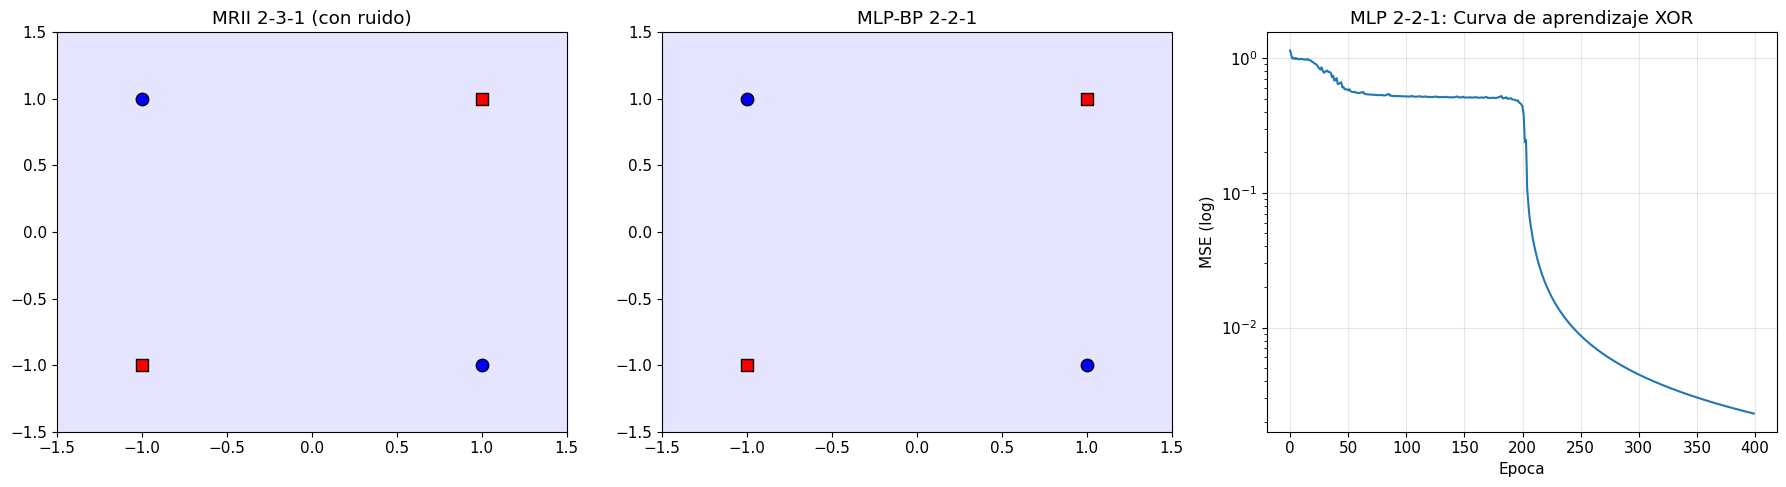


Tabla: tabs/tab_xor.tex
E5 completado.


In [16]:
# ===================================================================
# E5: XOR -- MRII vs MLP-Backprop (H3)
# ===================================================================
print("\n" + "="*60)
print("E5: XOR -- MRII vs MLP-Backprop")
print("="*60)

n_trials_xor = 20
results_xor = {}

# MRII 2-2-1 sin ruido
print("\n--- MRII 2-2-1 SIN ruido ---")
success_mrii_no_noise = 0
epochs_mrii_no_noise = []
for seed in range(n_trials_xor):
    mrii = MadalineII([2, 2, 1], seed=seed)
    hist = mrii.fit(X_xor, d_xor, max_epochs=150, alpha_out=0.5,
                     patience=200, noise_sigma=0.0, verbose=False, seed=seed+1000)
    yp = mrii.predict(X_xor)
    if hamming_error(d_xor, yp) == 0:
        success_mrii_no_noise += 1
        epochs_mrii_no_noise.append(np.argmin(hist['hamming_history']) + 1)
results_xor['MRII 2-2-1 sin ruido'] = (success_mrii_no_noise, epochs_mrii_no_noise)
print(f"  Exito: {success_mrii_no_noise}/{n_trials_xor}")

# MRII 2-2-1 CON ruido
print("\n--- MRII 2-2-1 CON ruido ---")
success_mrii_noise = 0
epochs_mrii_noise = []
for seed in range(n_trials_xor):
    mrii = MadalineII([2, 2, 1], seed=seed)
    hist = mrii.fit(X_xor, d_xor, max_epochs=150, alpha_out=0.5,
                     patience=15, noise_sigma=0.15, verbose=False, seed=seed+1000)
    yp = mrii.predict(X_xor)
    if hamming_error(d_xor, yp) == 0:
        success_mrii_noise += 1
        epochs_mrii_noise.append(np.argmin(hist['hamming_history']) + 1)
results_xor['MRII 2-2-1 + ruido'] = (success_mrii_noise, epochs_mrii_noise)
print(f"  Exito: {success_mrii_noise}/{n_trials_xor}")

# MRII 2-3-1 CON ruido
print("\n--- MRII 2-3-1 CON ruido ---")
success_mrii_3 = 0
epochs_mrii_3 = []
for seed in range(n_trials_xor):
    mrii = MadalineII([2, 3, 1], seed=seed)
    hist = mrii.fit(X_xor, d_xor, max_epochs=150, alpha_out=0.5,
                     patience=15, noise_sigma=0.15, verbose=False, seed=seed+1000)
    yp = mrii.predict(X_xor)
    if hamming_error(d_xor, yp) == 0:
        success_mrii_3 += 1
        epochs_mrii_3.append(np.argmin(hist['hamming_history']) + 1)
results_xor['MRII 2-3-1 + ruido'] = (success_mrii_3, epochs_mrii_3)
print(f"  Exito: {success_mrii_3}/{n_trials_xor}")

# MLP 2-2-1 backprop
print("\n--- MLP 2-2-1 Backprop ---")
success_mlp_2 = 0
epochs_mlp_2 = []
for seed in range(n_trials_xor):
    mlp = MLP([2, 2, 1], mu=0.1, momentum=0.0, seed=seed)
    hist = mlp.fit(X_xor, d_xor.reshape(-1,1), epochs=400, seed=seed+2000)
    yp = mlp.predict_batch(X_xor).flatten()
    yp_bin = np.sign(yp); yp_bin[yp_bin==0] = 1.0
    if accuracy_fn(d_xor, yp_bin) == 1.0:
        success_mlp_2 += 1
        epochs_mlp_2.append(np.argmax(hist['acc_history'] >= 1.0) + 1 if np.any(hist['acc_history'] >= 1.0) else 400)
results_xor['MLP-BP 2-2-1'] = (success_mlp_2, epochs_mlp_2)
print(f"  Exito: {success_mlp_2}/{n_trials_xor}")

# MLP 2-3-1 backprop
print("\n--- MLP 2-3-1 Backprop ---")
success_mlp_3 = 0
epochs_mlp_3 = []
for seed in range(n_trials_xor):
    mlp = MLP([2, 3, 1], mu=0.1, momentum=0.0, seed=seed)
    hist = mlp.fit(X_xor, d_xor.reshape(-1,1), epochs=400, seed=seed+2000)
    yp = mlp.predict_batch(X_xor).flatten()
    yp_bin = np.sign(yp); yp_bin[yp_bin==0] = 1.0
    if accuracy_fn(d_xor, yp_bin) == 1.0:
        success_mlp_3 += 1
        epochs_mlp_3.append(np.argmax(hist['acc_history'] >= 1.0) + 1 if np.any(hist['acc_history'] >= 1.0) else 400)
results_xor['MLP-BP 2-3-1'] = (success_mlp_3, epochs_mlp_3)
print(f"  Exito: {success_mlp_3}/{n_trials_xor}")

# Figura XOR: regiones de decision
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MRII 2-3-1 exitosa
mrii_best = MadalineII([2, 3, 1], seed=5)
mrii_best.fit(X_xor, d_xor, max_epochs=150, alpha_out=0.5, patience=15, noise_sigma=0.15, seed=5000)

def plot_decision_region(ax, model, X, d, title, is_mlp=False):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if is_mlp:
        Z = np.array([np.sign(model.predict_batch(g.reshape(1,-1))[0,0]) for g in grid])
    else:
        Z = np.array([np.sign(model.forward(g)[0]) for g in grid])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=['#FFCCCC','#CCCCFF'], alpha=0.5)
    ax.scatter(X[d==1,0], X[d==1,1], c='blue', s=80, edgecolors='k')
    ax.scatter(X[d==-1,0], X[d==-1,1], c='red', s=80, edgecolors='k', marker='s')
    ax.set_title(title)

plot_decision_region(axes[0], mrii_best, X_xor, d_xor, 'MRII 2-3-1 (con ruido)')

# MLP 2-2-1 exitoso
mlp_xor = MLP([2, 2, 1], mu=0.1, momentum=0.0, seed=3)
mlp_xor.fit(X_xor, d_xor.reshape(-1,1), epochs=400, seed=3000)
plot_decision_region(axes[1], mlp_xor, X_xor, d_xor, 'MLP-BP 2-2-1', is_mlp=True)

# Curva MSE MLP
mlp_xor2 = MLP([2, 2, 1], mu=0.1, momentum=0.0, seed=7)
hist_plot = mlp_xor2.fit(X_xor, d_xor.reshape(-1,1), epochs=400, seed=7000)
axes[2].semilogy(hist_plot['mse_history'])
axes[2].set_xlabel('Epoca'); axes[2].set_ylabel('MSE (log)')
axes[2].set_title('MLP 2-2-1: Curva de aprendizaje XOR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig('figs/fig_xor.png', dpi=200, bbox_inches='tight'); plt.show()

# Tabla XOR
def fmt_epochs(elist):
    if len(elist) == 0: return '--'
    return str(int(np.median(elist)))

tab_xor = []
tab_xor.append('\\begin{tabular}{@{}lccc@{}}')
tab_xor.append('\\toprule')
tab_xor.append('Configuracion & Tasa exito & Mediana epocas & \\\\')
tab_xor.append('\\midrule')
for name, (succ, eps) in results_xor.items():
    tab_xor.append(f'{name} & {succ}/{n_trials_xor} & {fmt_epochs(eps)} \\\\')
tab_xor.append('\\bottomrule')
tab_xor.append('\\end{tabular}')
with open('tabs/tab_xor.tex', 'w', encoding='utf-8') as f:
    f.write('\n'.join(tab_xor))
print("\nTabla: tabs/tab_xor.tex")
print("E5 completado.")


\n============================================================
E6: MLP en Iris + two-moons + Wine + MNIST
\n--- Perceptron en Iris ---
  Setosa vs Resto: converge en 2 epocas, acc test=1.0000
  Versicolor vs Virginica: converge=5, acc test=0.8333
\n--- MLP 4-8-3 en Iris ---
  mu=0.001, eta=0.0: acc train=0.9810, acc test=0.9111, ep95=62, t=0.99s
  mu=0.001, eta=0.9: acc train=0.9810, acc test=0.9111, ep95=62, t=1.04s
  mu=0.010, eta=0.0: acc train=1.0000, acc test=0.9111, ep95=7, t=0.98s
  mu=0.010, eta=0.9: acc train=1.0000, acc test=0.9111, ep95=7, t=1.08s
  mu=0.050, eta=0.0: acc train=1.0000, acc test=0.9111, ep95=4, t=1.03s
  mu=0.050, eta=0.9: acc train=1.0000, acc test=0.9111, ep95=4, t=1.08s
\nMejor configuracion: mu=0.05, eta=0, acc test=0.9111


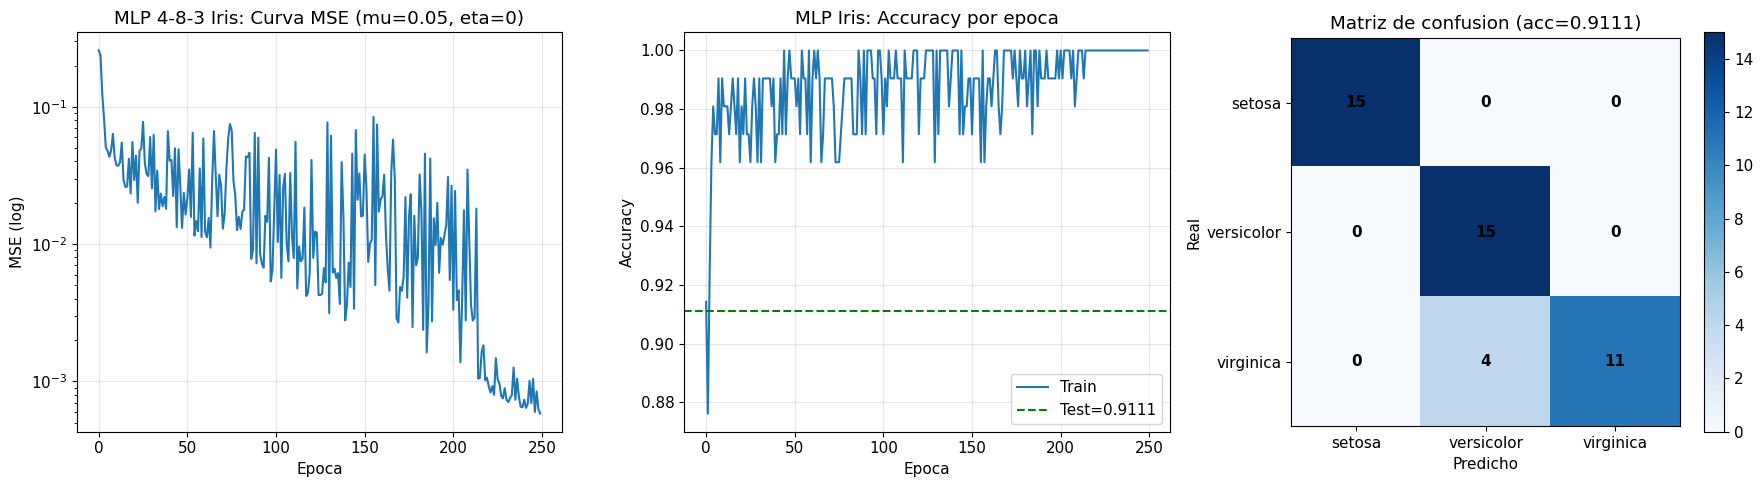

\nRelevancia de variables (norma L2 pesos capa 1):
  sepal length (cm): 1.50 (6.4%)
  sepal width (cm): 4.54 (19.2%)
  petal length (cm): 6.23 (26.4%)
  petal width (cm): 11.32 (48.0%)
Tablas: tabs/tab_iris.tex, tabs/tab_relevancia.tex
\n--- MLP 2-8-1 en two-moons ---
  MLP 2-8-1 two-moons: acc test = 93.3%


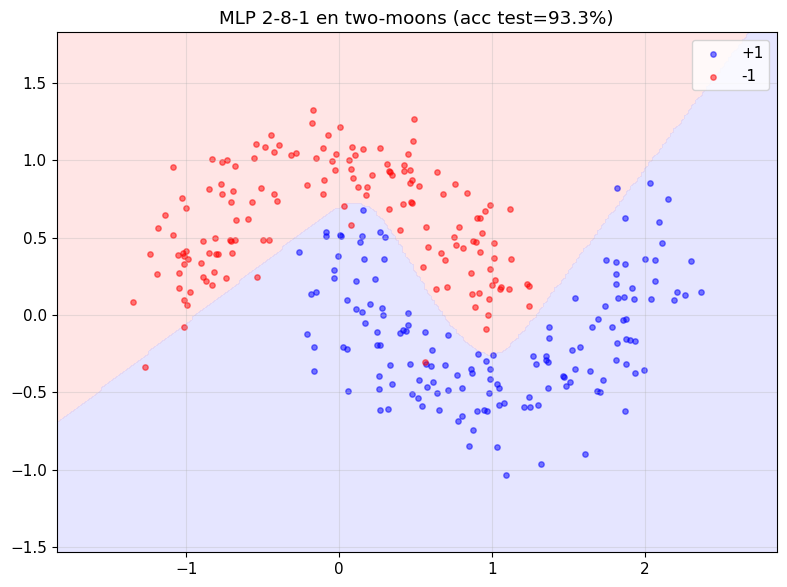

\n--- Clasificadores lineales en Wine ---
  alpha-LMS: acc test=96.3%, MSE train=0.1235
  mu-LMS:    acc test=98.1%, MSE train=0.1198
  Wiener:    acc test=98.1%


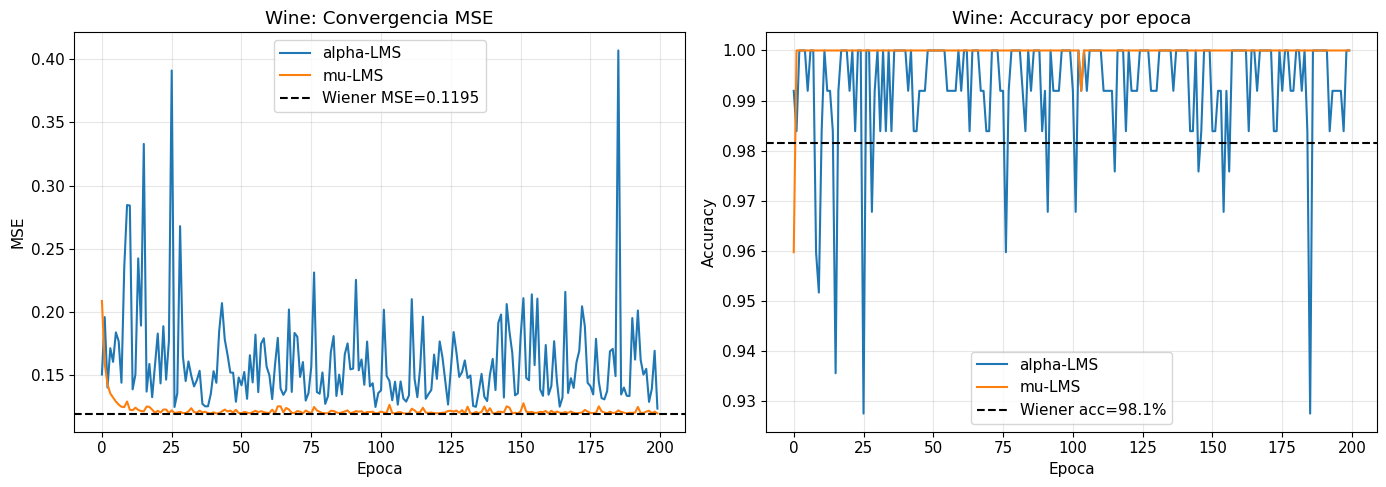

\n--- MLP 64-16-5 en MNIST-04 ---
  MLP 64-16-5: acc train=1.0000, acc test=0.9852, tiempo=3.9s


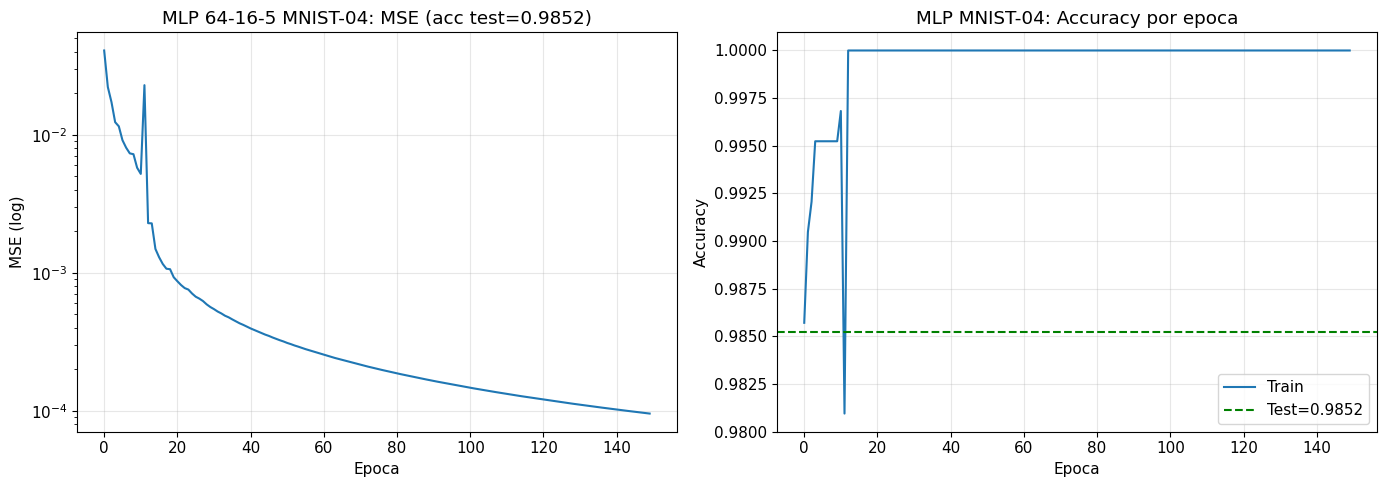

E6 completado.


In [18]:
# ===================================================================
# E6: MLP EN DATASETS REALES
# ===================================================================
print("\\n" + "="*60)
print("E6: MLP en Iris + two-moons + Wine + MNIST")
print("="*60)

# --- Perceptron en Iris (preambulo: demostrar separabilidad de setosa) ---
print("\\n--- Perceptron en Iris ---")
Wp_setosa, hp_setosa = train_perceptron(X_iris_train_n, d_setosa_train, alpha=1.0, max_epochs=200)
yp_setosa_test = np.sign(np.dot(add_bias(X_iris_test_n), Wp_setosa)); yp_setosa_test[yp_setosa_test==0]=1.0
acc_setosa = accuracy_fn(d_setosa_test, yp_setosa_test)
print(f"  Setosa vs Resto: converge en {hp_setosa['epochs_to_converge']} epocas, acc test={acc_setosa:.4f}")

Wp_vv, hp_vv = train_perceptron(X_vv_train, d_vv_train, alpha=1.0, max_epochs=200)
yp_vv = np.sign(np.dot(add_bias(X_vv_test), Wp_vv)); yp_vv[yp_vv==0]=1.0
acc_vv = accuracy_fn(d_vv_test, yp_vv)
print(f"  Versicolor vs Virginica: converge={hp_vv['epochs_to_converge']}, acc test={acc_vv:.4f}")

# --- MLP Iris 4-8-3 ---
print("\\n--- MLP 4-8-3 en Iris ---")
mu_grid = [0.001, 0.01, 0.05]
eta_grid = [0, 0.9]
best_acc = 0
best_config = None
results_iris = []

for mu in mu_grid:
    for eta in eta_grid:
        mlp_iris = MLP([4, 8, 3], mu=mu, momentum=eta, seed=7)
        t0 = time.perf_counter()
        hist = mlp_iris.fit(X_iris_train_n, d_iris_train_oh, epochs=250, verbose=False, seed=11)
        elapsed = time.perf_counter() - t0
        acc_train = mlp_iris.accuracy(X_iris_train_n, d_iris_train_oh)
        acc_test = mlp_iris.accuracy(X_iris_test_n, d_iris_test_oh)
        # Epocas para llegar a 95% train
        ep95 = np.argmax(hist['acc_history'] >= 0.95) + 1 if np.any(hist['acc_history'] >= 0.95) else 250
        results_iris.append((mu, eta, acc_train, acc_test, ep95, elapsed))
        print(f"  mu={mu:.3f}, eta={eta:.1f}: acc train={acc_train:.4f}, acc test={acc_test:.4f}, ep95={ep95}, t={elapsed:.2f}s")
        if acc_test > best_acc or (acc_test == best_acc and ep95 < (best_config[4] if best_config else 999)):
            best_acc = acc_test
            best_config = (mu, eta, acc_train, acc_test, ep95, elapsed, mlp_iris, hist)

print(f"\\nMejor configuracion: mu={best_config[0]}, eta={best_config[1]}, acc test={best_config[3]:.4f}")

# Figura Iris
best_mlp = best_config[6]
best_hist = best_config[7]
# Calcular matriz de confusion
preds_test = best_mlp.predict_batch(X_iris_test_n)
y_pred_test = np.argmax(preds_test, axis=1)
y_true_test = y_iris_test
cm = confusion_matrix(y_true_test, y_pred_test)
acc_test_cm = accuracy_score(y_true_test, y_pred_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].semilogy(best_hist['mse_history'])
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE (log)')
axes[0].set_title(f'MLP 4-8-3 Iris: Curva MSE (mu={best_config[0]}, eta={best_config[1]})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(best_hist['acc_history'], label='Train')
axes[1].axhline(y=best_config[3], color='green', linestyle='--', label=f'Test={best_config[3]:.4f}')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('MLP Iris: Accuracy por epoca')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

im = axes[2].imshow(cm, cmap='Blues', interpolation='nearest')
axes[2].set_xticks([0,1,2]); axes[2].set_yticks([0,1,2])
axes[2].set_xticklabels(iris.target_names); axes[2].set_yticklabels(iris.target_names)
axes[2].set_xlabel('Predicho'); axes[2].set_ylabel('Real')
axes[2].set_title(f'Matriz de confusion (acc={acc_test_cm:.4f})')
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, str(cm[i,j]), ha='center', va='center', fontweight='bold')
plt.colorbar(im, ax=axes[2])
plt.tight_layout(); plt.savefig('figs/fig_iris_mlp.png', dpi=200, bbox_inches='tight'); plt.show()

# Relevancia de variables (norma L2 pesos primera capa por atributo)
W1_iris = best_mlp.W[0][:, 1:]  # Sin columna bias
relevancia = np.linalg.norm(W1_iris, axis=0)
total = np.sum(relevancia)
feat_names = iris.feature_names
print("\\nRelevancia de variables (norma L2 pesos capa 1):")
for name, r in zip(feat_names, relevancia):
    print(f"  {name}: {r:.2f} ({r/total*100:.1f}%)")

# Tabla Iris
tab_iris = []
tab_iris.append('\\\\begin{tabular}{@{}lccccc@{}}')
tab_iris.append('\\\\toprule')
tab_iris.append('$\\\\mu$ & $\\\\eta$ & Acc. train & Acc. test & Ep. a 95\\\\% & Tiempo (s) \\\\\\\\')
tab_iris.append('\\\\midrule')
for mu, eta, atr, ate, ep95, t in results_iris:
    tab_iris.append(f'{mu:.3f} & {eta:.1f} & {atr*100:.1f}\\\\% & {ate*100:.1f}\\\\% & {ep95} & {t:.2f} \\\\\\\\')
tab_iris.append('\\\\bottomrule')
tab_iris.append('\\\\end{tabular}')
with open('tabs/tab_iris.tex', 'w', encoding='utf-8') as f:
    f.write('\\n'.join(tab_iris))

# Tabla relevancia
tab_rel = []
tab_rel.append('\\\\begin{tabular}{@{}lcc@{}}')
tab_rel.append('\\\\toprule')
tab_rel.append('Atributo & $\\\\|W_1\\\\|_2$ & Contribucion (\\\\%) \\\\\\\\')
tab_rel.append('\\\\midrule')
for name, r in zip(feat_names, relevancia):
    tab_rel.append(f'{name} & {r:.2f} & {r/total*100:.1f}\\\\% \\\\\\\\')
tab_rel.append('\\\\bottomrule')
tab_rel.append('\\\\end{tabular}')
with open('tabs/tab_relevancia.tex', 'w', encoding='utf-8') as f:
    f.write('\\n'.join(tab_rel))
print("Tablas: tabs/tab_iris.tex, tabs/tab_relevancia.tex")

# --- Two-moons con MLP ---
print("\\n--- MLP 2-8-1 en two-moons ---")
mlp_moons = MLP([2, 8, 1], mu=0.02, momentum=0.9, seed=42)
X_mt, X_mv, d_mt, d_mv = train_test_split(X_moons, d_moons, test_size=0.3, random_state=42)
hist_moons = mlp_moons.fit(X_mt, d_mt.reshape(-1,1), epochs=300, verbose=False, seed=11)
yp_moons = mlp_moons.predict_batch(X_mv).flatten()
yp_moons_bin = np.sign(yp_moons); yp_moons_bin[yp_moons_bin==0]=1.0
acc_moons = accuracy_fn(d_mv, yp_moons_bin)
print(f"  MLP 2-8-1 two-moons: acc test = {acc_moons*100:.1f}%")

# Figura moons
fig, ax = plt.subplots(figsize=(8, 6))
x_min, x_max = X_moons[:,0].min()-0.5, X_moons[:,0].max()+0.5
y_min, y_max = X_moons[:,1].min()-0.5, X_moons[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([np.sign(mlp_moons.predict_batch(g.reshape(1,-1))[0,0]) for g in grid])
Z = Z.reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=['#FFCCCC','#CCCCFF'], alpha=0.5)
ax.scatter(X_moons[d_moons==1,0], X_moons[d_moons==1,1], c='blue', alpha=0.5, s=15, label='+1')
ax.scatter(X_moons[d_moons==-1,0], X_moons[d_moons==-1,1], c='red', alpha=0.5, s=15, label='-1')
ax.set_title(f'MLP 2-8-1 en two-moons (acc test={acc_moons*100:.1f}%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_moons.png', dpi=200, bbox_inches='tight'); plt.show()

# --- Wine con alpha-LMS y mu-LMS ---
print("\\n--- Clasificadores lineales en Wine ---")
Wa_wine, ha_wine = train_alpha_lms(X_wine_train_n, d_wt, alpha=0.5, max_epochs=200)
Wm_wine, hm_wine = train_mu_lms(X_wine_train_n, d_wt, mu=0.01, max_epochs=200)
Ww_wine = wiener_solution(X_wine_train_n, d_wt)

Xb_wt = add_bias(X_wine_train_n); Xb_wv = add_bias(X_wine_test_n)
yp_wine_a = np.sign(np.dot(Xb_wv, Wa_wine)); yp_wine_a[yp_wine_a==0]=1.0
yp_wine_m = np.sign(np.dot(Xb_wv, Wm_wine)); yp_wine_m[yp_wine_m==0]=1.0
yp_w = np.sign(np.dot(Xb_wv, Ww_wine)); yp_w[yp_w==0]=1.0
acc_wine_a = accuracy_fn(d_wv, yp_wine_a)
acc_wine_m = accuracy_fn(d_wv, yp_wine_m)
acc_wine_wiener = accuracy_fn(d_wv, yp_w)
print(f"  alpha-LMS: acc test={acc_wine_a*100:.1f}%, MSE train={ha_wine['mse_history'][-1]:.4f}")
print(f"  mu-LMS:    acc test={acc_wine_m*100:.1f}%, MSE train={hm_wine['mse_history'][-1]:.4f}")
print(f"  Wiener:    acc test={acc_wine_wiener*100:.1f}%")

# Figura Wine
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ha_wine['mse_history'], label='alpha-LMS')
ax1.plot(hm_wine['mse_history'], label='mu-LMS')
mse_w_wiener = mse_loss(d_wt, np.dot(Xb_wt, Ww_wine))
ax1.axhline(y=mse_w_wiener, color='black', linestyle='--', label=f'Wiener MSE={mse_w_wiener:.4f}')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('MSE')
ax1.set_title('Wine: Convergencia MSE')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ha_wine['acc_history'], label='alpha-LMS')
ax2.plot(hm_wine['acc_history'], label='mu-LMS')
ax2.axhline(y=acc_wine_wiener, color='black', linestyle='--', label=f'Wiener acc={acc_wine_wiener*100:.1f}%')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Accuracy')
ax2.set_title('Wine: Accuracy por epoca')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_wine.png', dpi=200, bbox_inches='tight'); plt.show()

# --- MNIST reducido con MLP ---
print("\\n--- MLP 64-16-5 en MNIST-04 ---")
mlp_digits = MLP([64, 16, 5], mu=0.01, momentum=0.0, seed=42)
t0 = time.perf_counter()
hist_digits = mlp_digits.fit(X_digits_train_n, d_digits_train_oh, epochs=150, verbose=False, seed=11)
t_digits = time.perf_counter() - t0
acc_digits_train = mlp_digits.accuracy(X_digits_train_n, d_digits_train_oh)
acc_digits_test = mlp_digits.accuracy(X_digits_test_n, d_digits_test_oh)
print(f"  MLP 64-16-5: acc train={acc_digits_train:.4f}, acc test={acc_digits_test:.4f}, tiempo={t_digits:.1f}s")

# Figura MNIST
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.semilogy(hist_digits['mse_history'])
ax1.set_xlabel('Epoca'); ax1.set_ylabel('MSE (log)')
ax1.set_title(f'MLP 64-16-5 MNIST-04: MSE (acc test={acc_digits_test:.4f})')
ax1.grid(True, alpha=0.3)

ax2.plot(hist_digits['acc_history'], label='Train')
ax2.axhline(y=acc_digits_test, color='green', linestyle='--', label=f'Test={acc_digits_test:.4f}')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Accuracy')
ax2.set_title('MLP MNIST-04: Accuracy por epoca')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_mnist.png', dpi=200, bbox_inches='tight'); plt.show()

print("E6 completado.")


E7: MRIII vs Backprop
Error relativo minimo: 5.05e-08 en Delta_s = 1.00e-08

--- Costo computacional por presentacion ---
  H=  4: BP=0.0201ms, MRIII=0.0701ms, ratio=3.5x (N_ada=7)
  H= 16: BP=0.0194ms, MRIII=0.2148ms, ratio=11.0x (N_ada=19)
  H= 64: BP=0.0312ms, MRIII=0.5881ms, ratio=18.9x (N_ada=67)
  H=256: BP=0.0341ms, MRIII=2.5297ms, ratio=74.1x (N_ada=259)


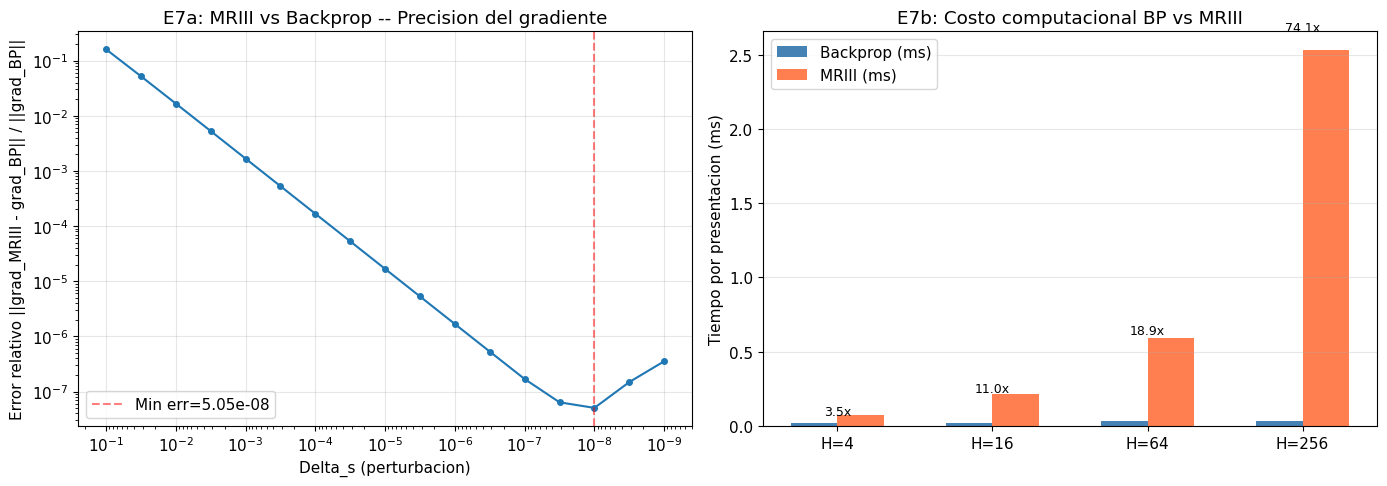

Tabla: tabs/tab_mriii.tex
E7 completado.


In [19]:
# ===================================================================
# E7: MRIII vs BACKPROP -- Equivalencia y costo (H4)
# ===================================================================
print("\n" + "="*60)
print("E7: MRIII vs Backprop")
print("="*60)

# Red 4-8-3 entrenada en Iris
net_e7 = MLP([4, 8, 3], mu=0.01, seed=5)
net_e7.fit(X_iris_train_n, d_iris_train_oh, epochs=50, seed=55)

# Tomar un patron de Iris (el primero)
x0 = X_iris_train_n[0]
d0 = d_iris_train_oh[0]

# (a) Comparar gradientes para distintos Delta_s
ds_values = np.logspace(-1, -9, 17)
errors_rel = []
for ds in ds_values:
    grad_mriii, _ = mriii_gradient(net_e7, x0, d0, ds=ds)
    grad_bp = backprop_gradient(net_e7, x0, d0)
    # Calcular error relativo (norma)
    flat_mriii = np.concatenate([g.flatten() for g in grad_mriii])
    flat_bp = np.concatenate([g.flatten() for g in grad_bp])
    err = np.linalg.norm(flat_mriii - flat_bp) / (np.linalg.norm(flat_bp) + 1e-15)
    errors_rel.append(err)

min_err_idx = np.argmin(errors_rel)
print(f"Error relativo minimo: {errors_rel[min_err_idx]:.2e} en Delta_s = {ds_values[min_err_idx]:.2e}")

# (b) Costo computacional BP vs MRIII
print("\n--- Costo computacional por presentacion ---")
hidden_sizes = [4, 16, 64, 256]
n_reps = 30
cost_results = []

for H in hidden_sizes:
    net_cost = MLP([4, H, 3], mu=0.01, seed=1)
    n_ada = sum(w.shape[0] for w in net_cost.W)
    
    # Tiempo backprop (1 forward + 1 backward)
    t0 = time.perf_counter()
    for _ in range(n_reps):
        net_cost.train_pattern(x0, d0)
    t_bp = (time.perf_counter() - t0) / n_reps * 1000  # ms
    
    # Tiempo MRIII (1 + N_Adalines forwards)
    t0 = time.perf_counter()
    for _ in range(n_reps):
        mriii_gradient(net_cost, x0, d0, ds=1e-6)
    t_mriii = (time.perf_counter() - t0) / n_reps * 1000  # ms
    
    ratio = t_mriii / t_bp if t_bp > 0 else 0
    cost_results.append((H, n_ada, t_bp, t_mriii, ratio))
    print(f"  H={H:3d}: BP={t_bp:.4f}ms, MRIII={t_mriii:.4f}ms, ratio={ratio:.1f}x (N_ada={n_ada})")

# Figura MRIII vs BP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (a) Error relativo vs Delta_s
ax1.loglog(ds_values, errors_rel, 'o-', markersize=4)
ax1.axvline(x=ds_values[min_err_idx], color='red', linestyle='--', alpha=0.5,
            label=f'Min err={errors_rel[min_err_idx]:.2e}')
ax1.set_xlabel('Delta_s (perturbacion)')
ax1.set_ylabel('Error relativo ||grad_MRIII - grad_BP|| / ||grad_BP||')
ax1.set_title('E7a: MRIII vs Backprop -- Precision del gradiente')
ax1.invert_xaxis()
ax1.legend(); ax1.grid(True, alpha=0.3)

# (b) Costo computacional
Hs = [r[0] for r in cost_results]
t_bps = [r[2] for r in cost_results]
t_mriiis = [r[3] for r in cost_results]
ratios = [r[4] for r in cost_results]
ax2.bar(np.arange(len(Hs))-0.15, t_bps, 0.3, label='Backprop (ms)', color='steelblue')
ax2.bar(np.arange(len(Hs))+0.15, t_mriiis, 0.3, label='MRIII (ms)', color='coral')
ax2.set_xticks(range(len(Hs)))
ax2.set_xticklabels([f'H={h}' for h in Hs])
ax2.set_ylabel('Tiempo por presentacion (ms)')
ax2.set_title('E7b: Costo computacional BP vs MRIII')
ax2.legend()

# Agregar ratios como texto
for i, r in enumerate(ratios):
    ax2.text(i, max(t_bps[i], t_mriiis[i])*1.05, f'{r:.1f}x', ha='center', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('figs/fig_mriii_bp.png', dpi=200, bbox_inches='tight'); plt.show()

# Tabla MRIII
tab_mriii = []
tab_mriii.append('\\begin{tabular}{@{}lcccc@{}}')
tab_mriii.append('\\toprule')
tab_mriii.append('Ocultas (H) & Adalines & BP (ms) & MRIII (ms) & Razon \\\\')
tab_mriii.append('\\midrule')
for H, n_ada, t_bp, t_mriii, ratio in cost_results:
    tab_mriii.append(f'{H} & {n_ada} & {t_bp:.4f} & {t_mriii:.4f} & {ratio:.1f}$\\times$ \\\\')
tab_mriii.append('\\bottomrule')
tab_mriii.append('\\end{tabular}')
with open('tabs/tab_mriii.tex', 'w', encoding='utf-8') as f:
    f.write('\n'.join(tab_mriii))
print("Tabla: tabs/tab_mriii.tex")
print("E7 completado.")


In [20]:
# ===================================================================
# TABLA RESUMEN CONSOLIDADA
# ===================================================================
print("\n" + "="*60)
print("Generando tabla resumen...")
print("="*60)

tab_resumen = []
tab_resumen.append('\\begin{tabular}{@{}llll@{}}')
tab_resumen.append('\\toprule')
tab_resumen.append('Exp. & Problema & Algoritmo & Resultado clave \\\\')
tab_resumen.append('\\midrule')
tab_resumen.append('E1 & Capacidad de Cover & Monte Carlo LP & $C_s\\approx 2N_w$, $C_d=N_w$ verificado \\\\')
tab_resumen.append(f'E2 & Datos separables & Perceptron, $\\alpha$-LMS, $\\mu$-LMS & Perceptron converge en {hp["epochs_to_converge"]} ep.; $\\mu$-LMS a {ang_m:.1f} deg de Wiener \\\\')
tab_resumen.append(f'E3 & Datos no separables & Perceptron, $\\alpha$-LMS, $\\mu$-LMS & $\\mu$-LMS mejor: {ma_m*100:.1f}\\% $\\pm${ma_s*100:.1f} vs Wiener {acc_wiener_ns*100:.1f}\\% \\\\')
tab_resumen.append('E4 & Superficies MSE & Adaline 2D & MSE signum tiene mesetas y optimos locales \\\\')
tab_resumen.append(f'E5 & XOR & MRII, MLP-BP & MRII+ruido {success_mrii_noise}/{n_trials_xor}, MLP-BP {success_mlp_2}/{n_trials_xor} \\\\')
tab_resumen.append(f'E6 & Iris (real) & MLP 4-8-3 & Mejor acc test={best_config[3]*100:.1f}\\% ($\\mu$={best_config[0]}, $\\eta$={best_config[1]}) \\\\')
tab_resumen.append(f'E6b & Two-moons & MLP 2-8-1 & Acc test={acc_moons*100:.1f}\\% \\\\')
tab_resumen.append(f'E6c & Wine (real) & $\\alpha$-LMS, $\\mu$-LMS, Wiener & Wiener acc={acc_wine_wiener*100:.1f}\\% \\\\')
tab_resumen.append(f'E6d & MNIST-04 & MLP 64-16-5 & Acc test={acc_digits_test*100:.1f}\\% \\\\')
tab_resumen.append(f'E7 & MRIII vs BP & Gradiente + costo & Err min={errors_rel[min_err_idx]:.2e} en $\\Delta s$={ds_values[min_err_idx]:.2e}; MRIII {ratios[1]:.0f}$\\times$ mas caro \\\\')
tab_resumen.append('\\bottomrule')
tab_resumen.append('\\end{tabular}')
with open('tabs/tab_resumen.tex', 'w', encoding='utf-8') as f:
    f.write('\n'.join(tab_resumen))
print("Tabla resumen: tabs/tab_resumen.tex")
print("\n✅ TODOS los experimentos completados.")
print("   Figuras en figs/")
print("   Tablas en tabs/")



Generando tabla resumen...
Tabla resumen: tabs/tab_resumen.tex

✅ TODOS los experimentos completados.
   Figuras en figs/
   Tablas en tabs/
